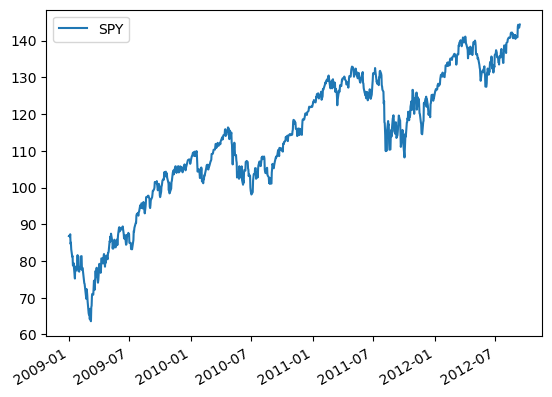

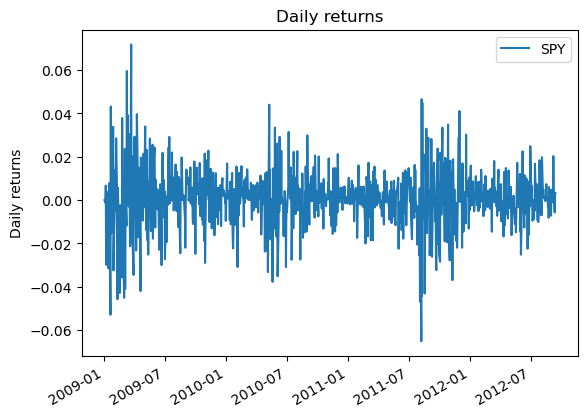

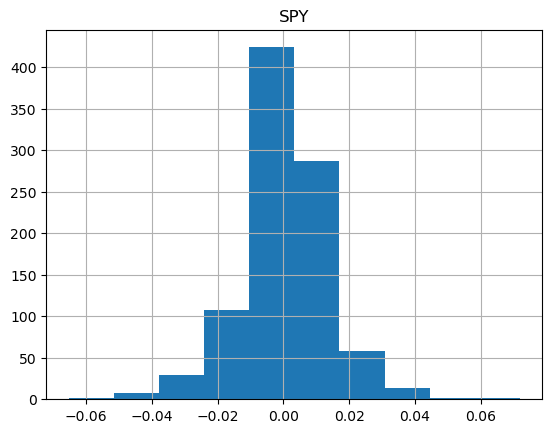

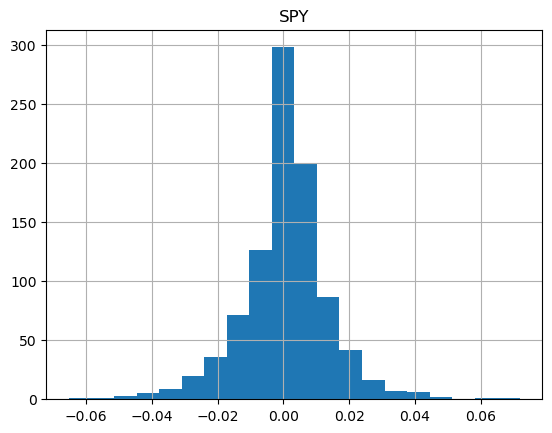

In [1]:

"""Plot a histogram."""

import pandas as pd
import matplotlib.pyplot as plt

from util import get_data, plot_data

def compute_daily_returns(df):
	"""Compute and return the daily return values."""
	daily_returns = df.copy()
	daily_returns[1:] = (df[1:] / df[:-1].values) - 1
	daily_returns.iloc[0, :] = 0 # set daily returns for row 0 to 0
	return daily_returns

def test_run():
	# Read data
	dates = pd.date_range('2009-01-01', '2012-12-31')
	symbols = ['SPY']
	df = get_data(symbols, dates)
	plot_data(df)
	
	# Compute daily returns
	daily_returns = compute_daily_returns(df)
	plot_data(daily_returns, title="Daily returns", ylabel="Daily returns")
	
	# Plot a histogram
	daily_returns.hist()  # default number of bins, 10
	daily_returns.hist(bins=20)  # changing no. of bins to 20
	plt.show()
	
if __name__ == "__main__":
	test_run()


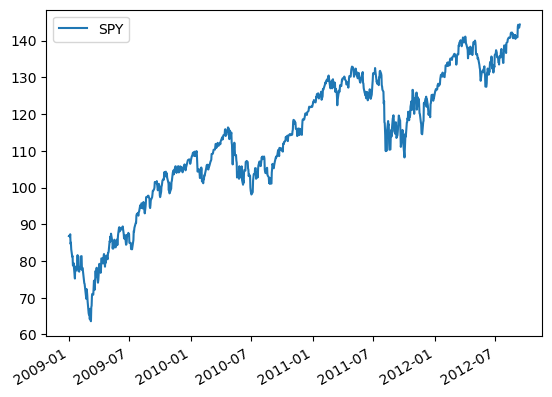

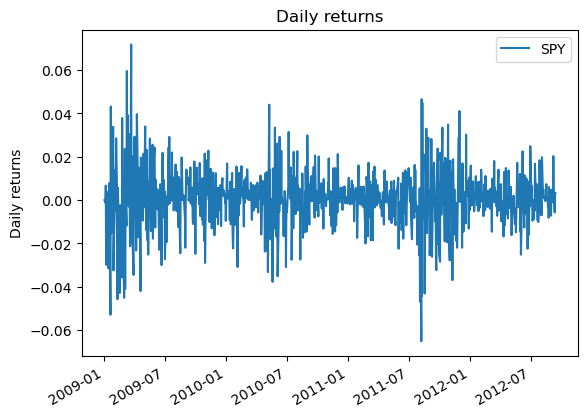

mean= 0.0006355783322251791
std= 0.013370490899409858


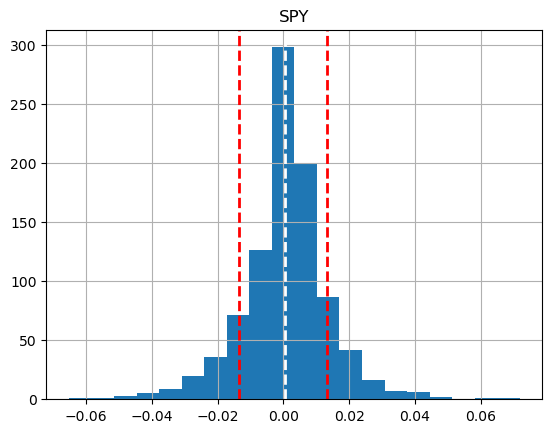

SPY    3.220278
dtype: float64


In [3]:
"""Computing Histogram Statistics"""

import pandas as pd
import matplotlib.pyplot as plt

from util import get_data, plot_data

def compute_daily_returns(df):
	"""Compute and return the daily return values."""
	daily_returns = df.copy()
	daily_returns[1:] = (df[1:] / df[:-1].values) - 1
	daily_returns.iloc[0, :] = 0 # set daily returns for row 0 to 0
	return daily_returns

def test_run():
	# Read data
	dates = pd.date_range('2009-01-01', '2012-12-31')
	symbols = ['SPY']
	df = get_data(symbols, dates)
	plot_data(df)
	
	# Compute daily returns
	daily_returns = compute_daily_returns(df)
	plot_data(daily_returns, title="Daily returns", ylabel="Daily returns")
	
	# Plot a histogram
	daily_returns.hist(bins=20)  # changing no. of bins to 20
	
	# Get mean and standard deviation
	mean = daily_returns['SPY'].mean()
	print ("mean=", mean)
	std = daily_returns['SPY'].std()
	print ("std=", std)
	
	plt.axvline(mean, color='w', linestyle='dashed', linewidth=2)
	plt.axvline(std, color='r', linestyle='dashed', linewidth=2)
	plt.axvline(-std, color='r', linestyle='dashed', linewidth=2)
	plt.show()
	
	# Compute kurtosis
	print (daily_returns.kurtosis())

test_run()

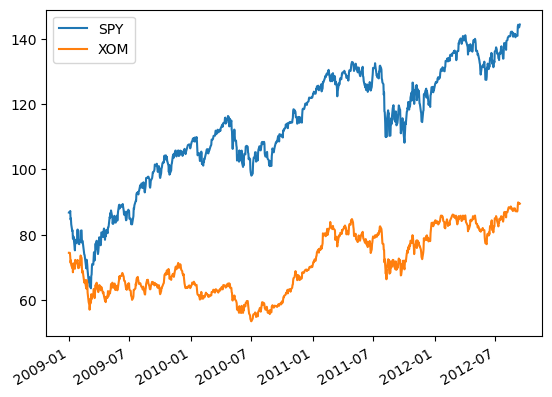

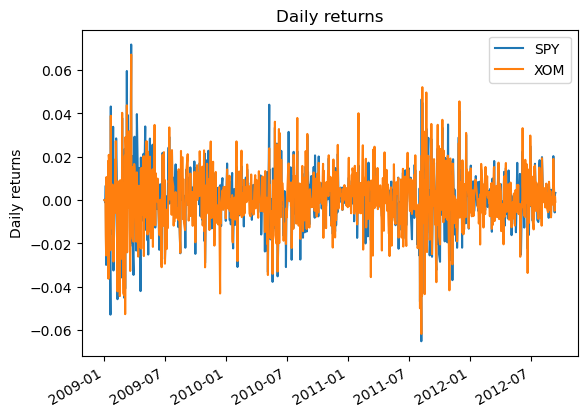

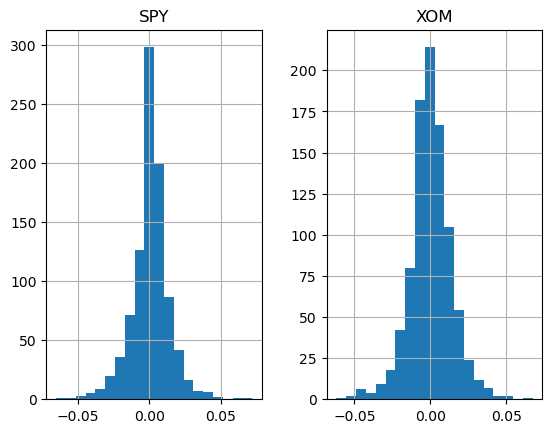

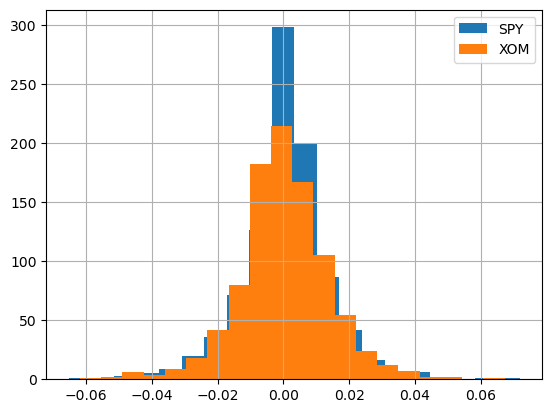

In [5]:
"""Plot Two Histograms together"""

import pandas as pd
import matplotlib.pyplot as plt

from util import get_data, plot_data

def compute_daily_returns(df):
	"""Compute and return the daily return values."""
	daily_returns = df.copy()
	daily_returns[1:] = (df[1:] / df[:-1].values) - 1
	daily_returns.iloc[0, :] = 0 # set daily returns for row 0 to 0
	return daily_returns
	
def test_run():
	# Read data
	dates = pd.date_range('2009-01-01', '2012-12-31')
	symbols = ['SPY', 'XOM']
	df = get_data(symbols, dates)
	plot_data(df)
	
	""" Two separate histograms ==========="""
	# Compute daily returns
	daily_returns = compute_daily_returns(df)
	plot_data(daily_returns, title="Daily returns", ylabel="Daily returns")
	
	# Plot a histogram
	daily_returns.hist(bins=20) 
	plt.show()

	""" Histograms on the same graph ======"""
	# Compute daily returns
	daily_returns = compute_daily_returns(df)
	
	# Compute and plot both histograms on the same chart
	daily_returns['SPY'].hist(bins=20, label="SPY")
	daily_returns['XOM'].hist(bins=20, label="XOM")
	plt.legend(loc='upper right')
	plt.show()
	
test_run()


beta_XOM=  0.8507462236725964
alpha_XOM= -0.0002468672766800917


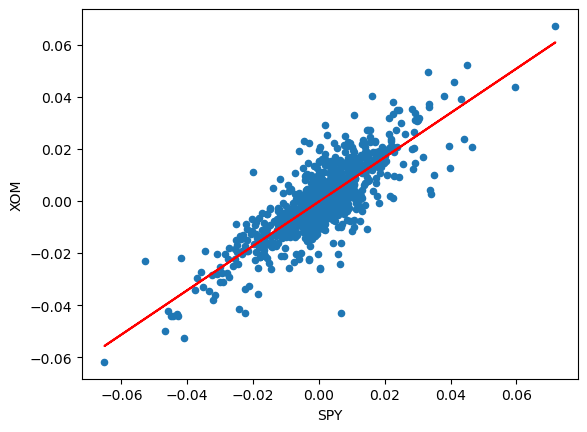

beta_GLD=  0.05976113483222504
alpha_GLD= 0.0007478811161601732


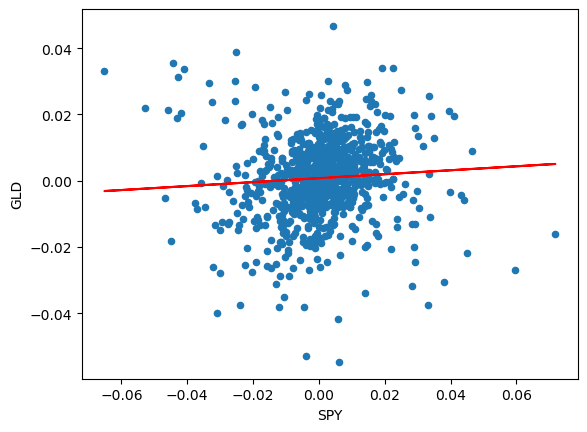

correlation:

          SPY       XOM       GLD
SPY  1.000000  0.820241  0.067324
XOM  0.820241  1.000000  0.069687
GLD  0.067324  0.069687  1.000000


In [23]:
"""Scatterplots."""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from util import get_data, plot_data

def compute_daily_returns(df):
	"""Compute and return the daily return values."""
	daily_returns = df.copy()
	daily_returns[1:] = (df[1:] / df[:-1].values) - 1
	daily_returns.iloc[0, :] = 0 # set daily returns for row 0 to 0
	return daily_returns
	
def test_run():
	# Read data
	dates = pd.date_range('2009-01-01', '2012-12-31')
	symbols = ['SPY', 'XOM', 'GLD']
	df = get_data(symbols, dates)
	
	# Compute daily returns
	daily_returns = compute_daily_returns(df)
	
	# Scatterplot SPY vs XOM
	daily_returns.plot(kind='scatter', x='SPY', y='XOM')
	beta_XOM, alpha_XOM= np.polyfit(daily_returns['SPY'], daily_returns['XOM'], 1)
	print ("beta_XOM= ", beta_XOM)
	print ("alpha_XOM=", alpha_XOM)
	plt.plot(daily_returns['SPY'], beta_XOM*daily_returns['SPY'] + alpha_XOM, '-',color='r')
	plt.show()
	
	# Scatterplot SPY vs GLD
	daily_returns.plot(kind='scatter', x='SPY', y='GLD')
	beta_GLD, alpha_GLD= np.polyfit(daily_returns['SPY'], daily_returns['GLD'], 1)
	print ("beta_GLD= ", beta_GLD)
	print ("alpha_GLD=", alpha_GLD)
	plt.plot(daily_returns['SPY'], beta_GLD*daily_returns['SPY'] + alpha_GLD, '-',color='r')
	plt.show()
	print("correlation:\n")
	print(daily_returns.corr(method='pearson'))

if __name__ == "__main__":
	test_run()